In [1]:
import os
import getpass

# os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API Key:")

# update os.environ["OPENAI_API_KEY"] to use os.getenv("OPENAI_API_KEY")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")


In [2]:
import nest_asyncio
nest_asyncio.apply()

In [3]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader

directory_loader = DirectoryLoader("data", glob="**/*.pdf", loader_cls=PyMuPDFLoader)

ai_usage_resources = directory_loader.load()

In [4]:
import tiktoken
from langchain.text_splitter import RecursiveCharacterTextSplitter

def tiktoken_len(text):
    tokens = tiktoken.encoding_for_model("gpt-4o").encode(
        text,
    )
    return len(tokens)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 750,
    chunk_overlap = 0,
    length_function = tiktoken_len,
)
ai_usage_chunks = text_splitter.split_documents(ai_usage_resources)

In [5]:
len(ai_usage_chunks)

71

In [6]:
max_chunk_length = 0

for chunk in ai_usage_chunks:
  max_chunk_length = max(max_chunk_length, tiktoken_len(chunk.page_content))

print(max_chunk_length)

735


In [7]:
# from langchain_qdrant import QdrantVectorStore
# from qdrant_client import QdrantClient
# from langchain_community.vectorstores import Qdrant
from langchain_openai.embeddings import OpenAIEmbeddings

embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")



In [ ]:
# from langchain_qdrant import QdrantVectorStore
# from qdrant_client import QdrantClient
# from qdrant_client.http.models import Distance, VectorParams

# client = QdrantClient(":memory:")

from langchain_qdrant import QdrantVectorStore
# from qdrant_client import QdrantClient
# from qdrant_client.http.models import Distance, VectorParams

# client = QdrantClient(host="localhost", port=6333)

In [20]:
qdrant_vectorstore = QdrantVectorStore.from_documents(
    documents=ai_usage_chunks,
    embedding=embedding_model,
    location=":memory:"
)

In [21]:
qdrant_retriever = qdrant_vectorstore.as_retriever()

In [22]:
from langchain_core.prompts import ChatPromptTemplate

HUMAN_TEMPLATE = """
#CONTEXT:
{context}

QUERY:
{query}

Use the provide context to answer the provided user query. Only use the provided context to answer the query. If you do not know the answer, or it's not contained in the provided context respond with "I don't know"
"""

chat_prompt = ChatPromptTemplate.from_messages([
    ("human", HUMAN_TEMPLATE)
])

In [23]:
from langchain_openai import ChatOpenAI

openai_chat_model = ChatOpenAI(model="gpt-4.1-nano")

In [24]:
from langgraph.graph import START, StateGraph
from typing_extensions import TypedDict
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser

class State(TypedDict):
  question: str
  context: list[Document]
  response: str

def retrieve(state: State) -> State:
  retrieved_docs = qdrant_retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

def generate(state: State) -> State:
  generator_chain = chat_prompt | openai_chat_model | StrOutputParser()
  response = generator_chain.invoke({"query" : state["question"], "context" : state["context"]})
  return {"response" : response}

graph_builder = StateGraph(State)
graph_builder = graph_builder.add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
rag_graph = graph_builder.compile()

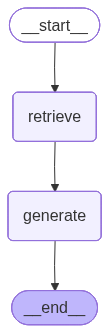

In [25]:
rag_graph

In [ ]:
## db Sept 17, 2025 - update question

response = rag_graph.invoke({"question" : "Do people use AI for their personal lives?"})

In [29]:
response["response"]

'Yes, people do use AI for their personal lives. The context indicates that, in terms of Self-Expression, some users engage with ChatGPT for Relationships and Personal Reflection (1.9%) and Games and Role Play (0.4%). Additionally, a significant portion of conversations involves expressing views or feelings, which falls under personal use.'

In [30]:
for context in response["context"]:
  print("Context:")
  print(context.page_content[:100])
  print("----")

Context:
to Games and Role Play. In contrast, Zao-Sanders (2025) estimates that Therapy/Companionship is
the 
----
Context:
suggests that most user Writing conversations with ChatGPT are requests to modify user inputs
rather
----
Context:
Vaswani, Ashish, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N.
Gomez, Lukasz Kai
----
Context:
References
Acemoglu, Daron, “The Simple Macroeconomics of AI,” Technical Report 32487, National Bure
----


In [31]:
response = rag_graph.invoke({"question" : "What is the airspeed velocity of an unladen swallow?"})

In [32]:
response["response"]

"I don't know"

In [ ]:
from uuid import uuid4

unique_id = uuid4().hex[0:8]

os.environ["LANGSMITH_TRACING"] = "true"
# os.environ["LANGCHAIN_TRACING_v2"] = "true"
# os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com/"
# os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com/"

os.environ["LANGSMITH_PROJECT"] = f"LangSmith - {unique_id}"

In [ ]:
# os.environ["LANGSMITH_API_KEY"] = getpass.getpass('Enter your LangSmith API key: ')
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")


Let's test our our first generation!

In [ ]:
rag_graph.invoke({"question" : "What is the maximum loan amount I can get from the government to go to school these days?"}, {"tags" : ["Demo Run"]})['response']

In [ ]:
!git clone https://github.com/AI-Maker-Space/DataRepository.git

In [ ]:
import pandas as pd

test_df = pd.read_csv("DataRepository/student_loan_rag_test_data.csv")

In [ ]:
from langsmith import Client

client = Client()

dataset_name = "langsmith-student-loan-rag-v0"

dataset = client.create_dataset(
    dataset_name=dataset_name, description="Student Loan RAG Test Questions"
)

for triplet in test_df.iterrows():
  triplet = triplet[1]
  client.create_example(
      inputs={"question" : triplet["question"], "context": triplet["context"]},
      outputs={"answer" : triplet["answer"]},
      dataset_id=dataset.id
  )

In [ ]:
def prepare_data_ref(run, example):
  return {
      "prediction" : run.outputs["response"],
      "reference" : example.outputs["answer"],
      "input" : example.inputs["question"]
  }

def prepare_data_noref(run, example):
  return {
      "prediction" : run.outputs["response"],
      "input" : example.inputs["question"]
  }

def prepare_context_ref(run, example):
  return {
      "prediction" : run.outputs["response"],
      "reference" : example.inputs["context"],
      "input" : example.inputs["question"]
  }

In [ ]:
from langsmith.evaluation import LangChainStringEvaluator, evaluate

eval_llm = ChatOpenAI(model="gpt-4o-mini", tags=["eval_llm"])

cot_qa_evaluator = LangChainStringEvaluator("cot_qa",  config={"llm":eval_llm}, prepare_data=prepare_context_ref)

unlabeled_dopeness_evaluator = LangChainStringEvaluator(
    "criteria",
    config={
        "criteria" : {
            "dopeness" : "Is the answer to the question dope, meaning cool - awesome - and legit?"
        },
        "llm" : eval_llm,
    },
    prepare_data=prepare_data_noref
)

labeled_score_evaluator = LangChainStringEvaluator(
    "labeled_score_string",
    config={
        "criteria": {
            "accuracy": "Is the generated answer the same as the reference answer?"
        },
        "llm" : eval_llm,
    },
    prepare_data=prepare_data_ref
)

base_rag_results = evaluate(
    rag_graph.invoke,
    data=dataset_name,
    evaluators=[
        cot_qa_evaluator,
        unlabeled_dopeness_evaluator,
        labeled_score_evaluator,
        ],
    experiment_prefix="Base RAG Evaluation"
)